In [19]:
# Import all necessary libraries
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib
from pylab import *
import numpy as np
import random

In [20]:
#Objetivo do código, simular uma regressão linear com 1 peso (a1) e sem viés (b=0), gerar ruído nos dados, calcular a função de custo (MSE) e ajustar a1 via solução exata e gradiente descendente

# A seed é usada para garantir números aleatorios iguais
np.random.seed(42)

In [21]:
# Quantidade de exemplos
N = 1000

### Função objetivo

$$y = 2x_1,$$
onde $a_0=0$, $a_1 = 2$ e o vetor $x_1$ é formado por $N$ amostras linearmente espaçadas dentro do intervalo de 0 a 10.

In [22]:
# Gerando os valores de entrada (features)
# Cria N pontos igualmente espaçados entre 0 e 10
#x1 representa os valores de entrada, features que vamos usar para as previsões
#reshape(N,1) transforma isso em um vetor coluna (1000 linhas, 1 coluna), vai ser usado em opeações matriciais(como multi0licação de pesos)
x1 = np.linspace(0, 10, N).reshape(N, 1)

# Função verdadeira sem ruídos, é uma reta.
y = 2.0*x1

# Adicionando ruído.
#Gera ruído aleatório com distribuição normal (Gaussiana) np.random.randn, média 0, desvio padrão 1.
#Multiplicando por 10 → o ruído tem desvio padrão 10, ou seja, tem mais "barulho".
w = 10.0*np.random.randn(N, 1)

# Cria a função observada com ruído.
# é essa função que o modelo vai tentar prever
y_noisy = y + w

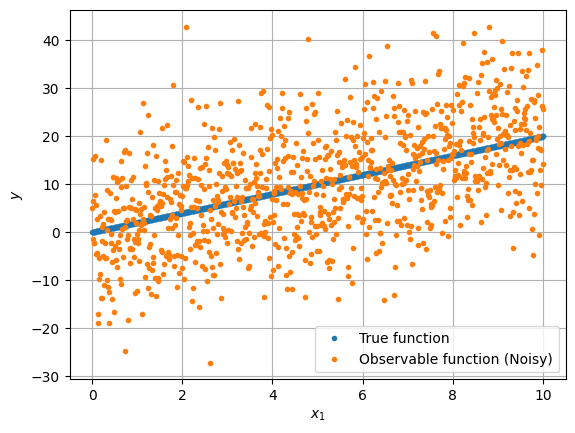

In [23]:
#Cria uma nova figura para o gráfico usando o matplotlib.pyplot.
fig = plt.figure()

#plota um grafico usando os valores de x1 e y. O ponto('.') indica que os pontos serãol desenhados como pontos(nao como linhas)
#label é o a legenda, vai dar o nome à linha (ou pontos, nesse caso)
plt.plot(x1, y,'.', label='True function')

#plota outro gráfico com os valores de x1, e y_noisy(dados com ruído)
#label nome da segunda linha
plt.plot(x1, y_noisy,'.', label='Observable function (Noisy)')

# define o rótulo do eixo x, como x1, usando notação do LaTex
plt.xlabel('$x_1$')

# define o rótulo do eixo y, como y, usando notação do LaTex
plt.ylabel('$y$')
#Exibe a legenda do gráfico com base nos rótulos definidos nas linhas de plotagem (True function e Observable function (Noisy)
plt.legend()

#Exibe uma grade no gráfico, facilitando a visualização dos dados.
plt.grid()

#Exibe o gráfico na tela.
plt.show()

## Função hipótese

$$\hat{y} = \hat{a}_1 x_1.$$

## Superfície de erro

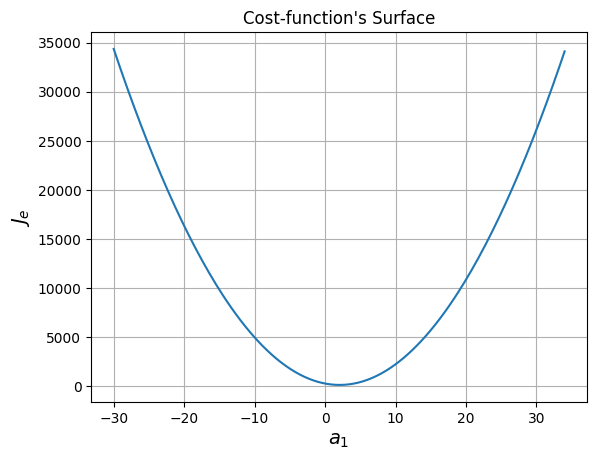

In [24]:
# Geraçao de valores para os parametros.
# M define o numero de pontos que serao gerados
M = 200

# A1 cria um vetor com 200 valores igualmente espaçãdos entre -30 e 34.  Esses valores são possíveis valores para o parâmetro A1, que será usado na função de hipótese do modelo.
A1 = np.linspace(-30.0, 34.0, M)

# Geração dos pontos para o gráfico da superfície da função de custo.

# J cria um vetor de 0 com tamanho M(200) para armazenar os valores da função de custo para cada valor A1
J = np.zeros((M))
#O loop for iter1 in range(0, M): itera sobre os valores de A1 para calcular o valor da função de custo J para cada um desses valores.
for iter1 in range(0, M):
    # função hipotese do modelo para o valor atual de A1.
    yhat = A1[iter1]*x1
    #calcula o valor da função de custo para o valor atual de A1. A função de custo é a soma dos quadrados das diferenças entre os valores reais (y_noisy) e os valores previstos (yhat), normalizada pelo número de pontos N.
    J[iter1] = (1.0/N)*np.sum(np.square(y_noisy - yhat));

# Plotando a superficie da função de custo.
fig = plt.figure()

# plota a função de custo J em função do parâmetro A1.
plt.plot(A1, J)

#define o rótulo do eixo X como $a_1$, com a notação matemática no estilo LaTeX.
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)

#define o título do gráfico como "Cost-function's Surface".
plt.title('Cost-function\'s Surface')
plt.grid()
#Exibe o gráfico.
plt.show()

## Solução ótima

In [25]:
# Solução em forma fechada, resolve diretamente o valor do parametro a1_opt que minimiza a função de custo.
# np.transpose(x1) -> Calcula a transposta de X1, se X1 for um vetor coluna, essa operação transforma em um linha
# np.transpose(x1).dot(x1) -> calcula o produto de X1^T (transposta de X1) com X1,ou seja X^T*X
# np. linalg.piv() -> Calcula a pseudo-inversa de X^T*X. A pseudo inversa é usada quando a matriz não é invertivel diretamente (por exemplo, quando ela não é quadrada ou não tem uma inversa). Isso resolve problemas numéricos em vez de usar a inversa direta.
# np.transpose(x1).dot(y_noisy) -> Calcula o produto entre X1^T (transposta de X1) e o vetor de valores reais ynoisy
# a1_opt -> Multiplicando a pseudo-inversa de X^T*X por X^T y, obtemoso valor ótimo de a1, que é a solução para o modelo de regressao linear
a1_opt = np.linalg.pinv(np.transpose(x1).dot(x1)).dot(np.transpose(x1).dot(y_noisy))


#Fazendo a previsão com o parâmetro a1 ótimo

# Aqui, calculamos as previsões yhat(valores previstos) usando o valor ótimo de a1 obtido na linha anterior. COmo estamos trabalhndo com uma regressão linear simples, a previsão é dada por yhat = a1 * x1, ou seja, multiplicando os valores de x1 pelo coeficiente a1.
yhat = a1_opt*x1

# Calculando o erro quadrático médio (MSE) ótimo
# np.power((y_noisy - yhat), 2)-> Calcula o erro quadrático para cada ponto, ou seja, a diferenca entro o valor realo ynoisy e o valor previsto yhat, e depois eleva ao quadrado essa diferença
# np.sum() SOma todos os erros quadrados
# (1.0/N) Normaliza a soma dividindo pelo número total de pontos N, o que nos dá a média dos erros quadrados. Isso é o erro quadrático médio (MSE - Mean Squared Error).
#Joptimum é o valor do erro quadrático médio ótimo para o valor de a1 calculado.
Joptimum = (1.0/N)*np.sum(np.power((y_noisy - yhat), 2))

print('a1:', a1_opt)
print('MSE ótimo:', Joptimum)

a1: [[2.05907466]]
MSE ótimo: 95.71148639345347


## Solução iterativa com o gradiente descendente

In [26]:
# Gradient-descent solution.

# numero maximo de iterações para o algoritmo de gradiente descendente
maxNumIter = 10000

# Learning rate(taxa de aprendizado).
# contra os passos a ser dado a cada iteração
#alpha = 0.00003
alpha = 0.00001

# Um vetor para armazenar os valores de a1 (coeficiente da regressão) em cada iteração.
a1_hist = np.zeros((maxNumIter,))
# Vetor para armazenar os valores da função de custo (ou erro) J em cada iteração
Jgd = np.zeros((maxNumIter,))

# Inicialização dos pesos.

# a1(peso) é inicializado com um valor arbitrário de -30. Esse valor será ajustado nas iterações
a1 = -30

# Armazena o valor inicial de a1 na primeira posição de a1_hist.
a1_hist[0] = a1

# Initial MSE.

#faz um previsão inicial de y multiplicando o valor de a1 pelo vetor x1
yhat = a1*x1

# calcula a função de custo inicial, que é o MSE entre os valores reais ynoisy e as previsoes yhat
Jgd[0] = (1.0/N)*np.sum(np.power(y_noisy - yhat, 2))

# Training loop.

# O algoritmo de gradiente descendente é executado dentro de um loop que atualiza o valor de a1 em cada iteração, até que o erro (diferença entre as iterações consecutivas) seja suficientemente pequeno ou o número máximo de iterações seja atingido.
error = 1
iteration = 0
while(error > 0.00001 and iteration < maxNumIter-1):

    # Hypothesis function.
    # calcula a previsão com o valor atual de a1
    h = a1*x1

    # Update weight with gradient information. (calculol do gradiente)
    # update -> calcula o gradiente, que é a derivada da função de custp em relação ao peso a1. O gradiente indica a direçao do maio aumento da função de custo, e é usado para atualizar a1 na direção oposta
    # a fórmula de gradiente descendete para atualizar o peso é: a1 = a1 - alfa * gradiente
    update = -x1.T.dot(y_noisy - h)
    a1 = a1 - alpha*update

    # Update weight history. (atualização do historico e função de custo)
    # a1_hist-> armazena o valor atualizado de a1 no vetor a1_hist
    a1_hist[iteration+1] = a1[0,0]

    # Update MSE with new weight value.
    # calcula as previsoes com o novo valor de a1
    yhat = a1*x1

    # calcula e armazena a nova função de custo (erro) J após a atualização de a1
    Jgd[iteration+1] = (1.0/N)*np.sum(np.power(y_noisy - yhat, 2))

    # MSE between subsequent iterations.
    # calcula a diferença(erro) entre o valor da função de custo da iteração anterior e da atual. Esse erro é usado para verificar a convergência do algoritmo. Se o erro for muito pequeno o algoritmo é interrompido
    error = np.abs(Jgd[iteration] - Jgd[iteration+1])

    # Iteration counter.
    # incrementa o contador de iterações para seguir o loop
    iteration += 1

**Observações**:

+ Essa versão do gradiente descendente é conhecida como gradiente descendente em batelada, pois todos os exemplos do conjunto de treinamento são usados para calcular o vetor gradiente.
+ O erro converge suavemente para o menor valor possível, sem variações (oscilações) de valor entre épocas.
    * **Época**: é quando terminamos de apresentar todos os exemplos ao algoritmo.
+ O tempo de convergência desta versão pode ser bem longo se o conjunto de treinamento for muito grande, dado que o modelo é apresentado a todos os exemplos a cada época.

## Comparando as soluções

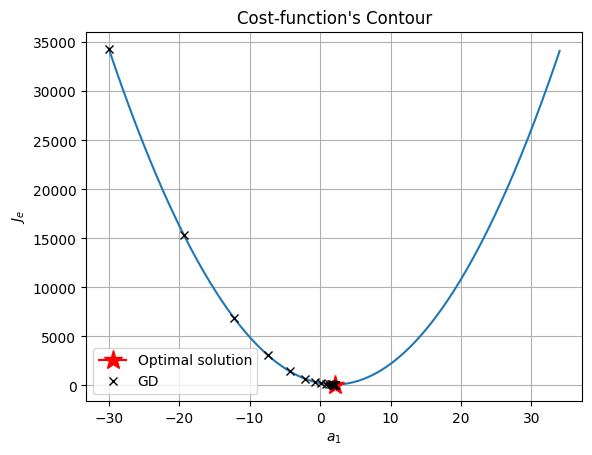

In [27]:
fig = plt.figure()
plt.plot(A1, J)
plt.xlabel('$a_1$')
plt.ylabel('$J_e$')
plt.title('Cost-function\'s Contour')
plt.plot(a1_opt[0], Joptimum, c='r', marker='*', markersize=14, label='Optimal solution')
plt.plot(a1_hist[0:iteration], Jgd[0:iteration], 'kx', label='GD')
plt.grid()
plt.legend()
plt.show()

## Erro de treinamento versus iteração

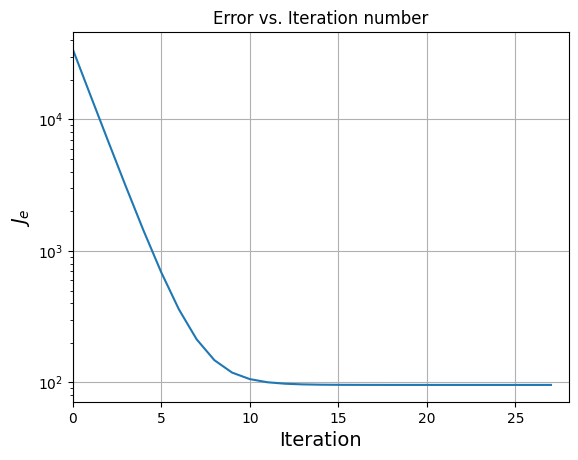

In [28]:
fig = plt.figure()

# plotando a função de custo em função das iteraçoes
# np.arrage: Cria um vetor que vai de 0 até o número de iterações
# iteration, representa o eixo x do gráfico ( o numero de iterações do gradiente descendete)
# Jdg[0:iteration]-> seleciona os valores da função de custo J(armazenados em jdg) correspondentes às iterações realizadas. Esses valores representam o erro ao longo das iterações do gradiente descendente.
plt.plot(np.arange(0, iteration), Jgd[0:iteration])

# Define os limites do eixo x para o gráfico, de modo que ele vá de 0 até o número total de iterações.
plt.xlim((0, iteration))

#Muda a escala do eixo y para um escala logaritmica  Isso é útil quando a função de custo diminui muito rapidamente e você quer visualizar melhor a mudança ao longo das iterações. A escala logarítmica ajuda a tornar mais visíveis os detalhes quando a função de custo está caindo em grande magnitude entre as iterações.
plt.yscale('log')

# adiciona rótulos e títulos ao gráfico
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
# adiciona uma grade
plt.grid()
# exibe o gráfico
plt.show()

## Comparando as soluções

In [30]:
# Compara as soluções das duas abordagens: solução ótima (fórmula normal) e a solução do gradiente descendente

# a1_opt contém o valor ótimo de a1, que foi obtido pela solução fechada. COmo a1_opt é um vetor(ou matriz), o índice [0][0] seleciona o primerio valor dessa matriz, que é o valor de a1 ótimo
# str converte o valor em string para que possa ser concatenado e impresso
print('a_opt: ' + str(a1_opt[0][0]))

# a1 contém o valor ótimo de a1, que foi obtido pela solução fechada. COmo a1_opt é um vetor(ou matriz), o índice [0][0] seleciona o primerio valor dessa matriz, que é o valor de a1 ótimo
# str converte o valor em string para que possa ser concatenado e impresso
print('a_gd: ' + str(a1[0][0]))

a_opt:  2.059074663632596
a_gd: 2.058701110619257
